#### Importing Libraries

In [130]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Optional (kalau pakai)
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#### LOAD DATASET


In [131]:
df = pd.read_csv('hypertension_dataset.csv')
df.info()

print("Jumlah data:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB
Jumlah data: (1985, 11)


In [132]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [133]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


#### Handling Missing Values

In [134]:
df["Medication"] = df["Medication"].fillna("None")
df.isnull().sum()


Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

In [135]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,None,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,None,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,None,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


#### EDA - Categorical

In [136]:
cat_cols = df.select_dtypes(include=['object']).columns

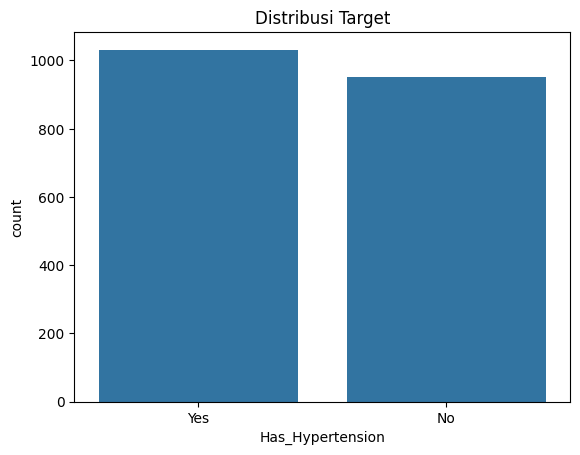

In [137]:
sns.countplot(x='Has_Hypertension', data=df)
plt.title('Distribusi Target')
plt.show()

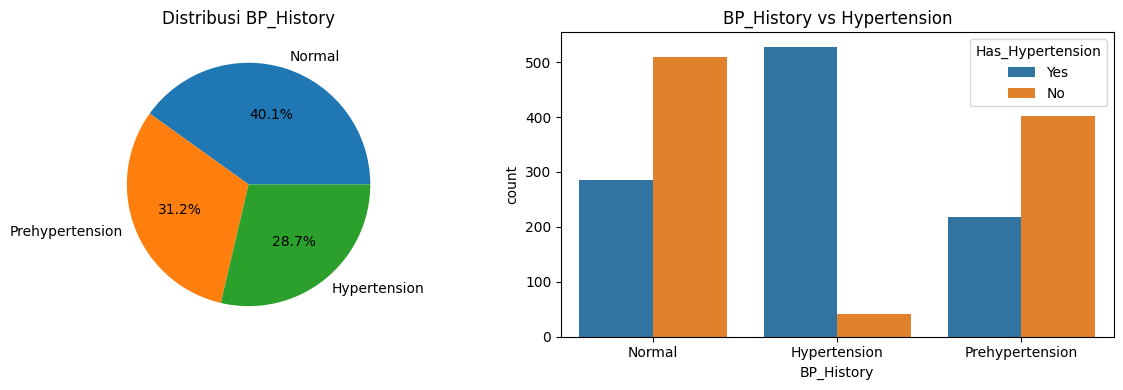

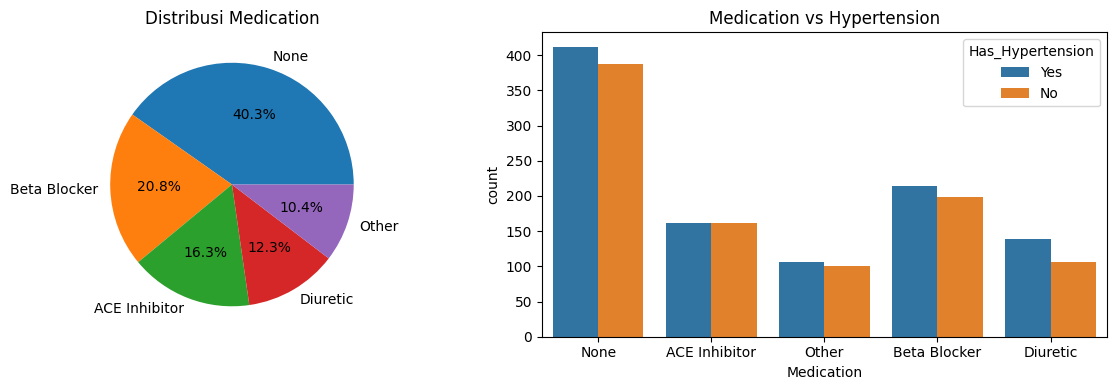

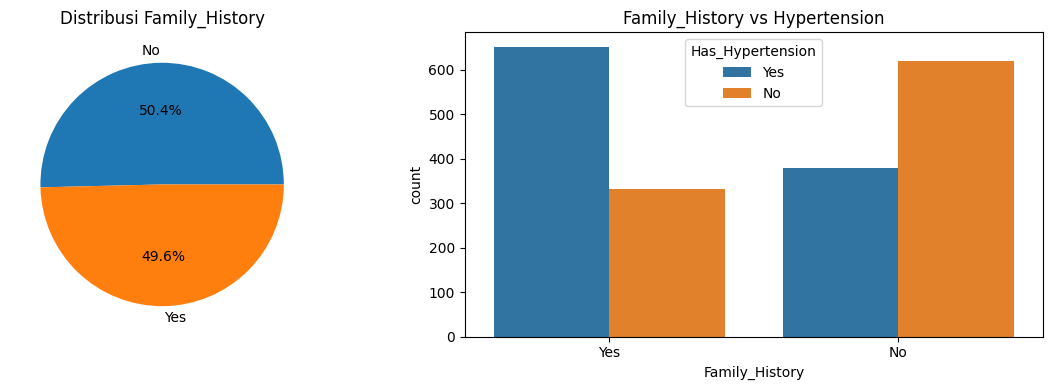

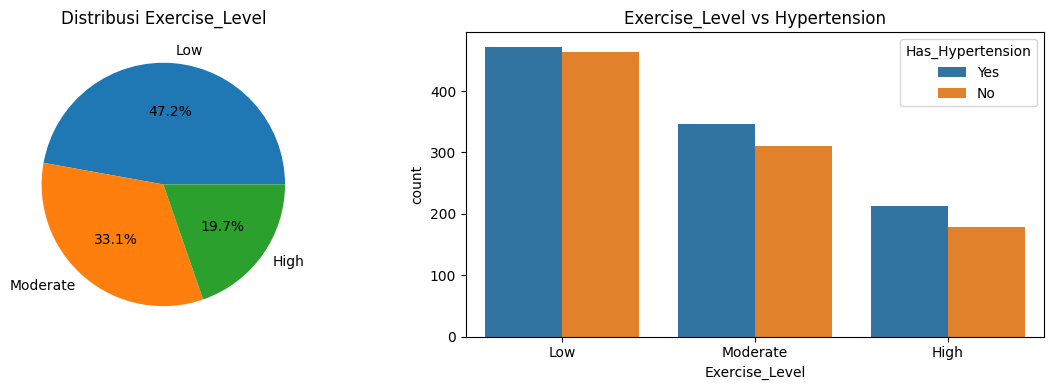

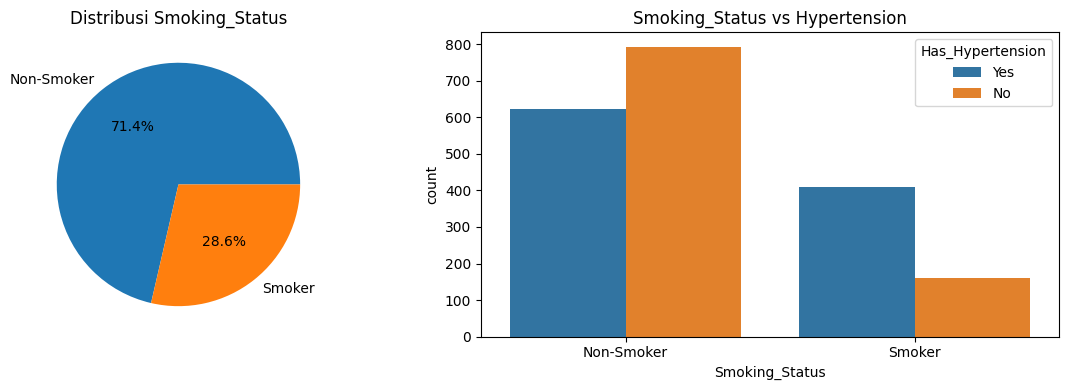

In [138]:
for col in cat_cols:
    if col != 'Has_Hypertension':
        plt.figure(figsize=(12,4))
        
        # Pie chart
        plt.subplot(1,2,1)
        df[col].value_counts().plot.pie(autopct='%1.1f%%')
        plt.title(f'Distribusi {col}')
        
        # Bar vs target
        plt.subplot(1,2,2)
        sns.countplot(x=col, hue='Has_Hypertension', data=df)
        plt.title(f'{col} vs Hypertension')
        
        plt.tight_layout()
        plt.show()

#### EDA - Numerical

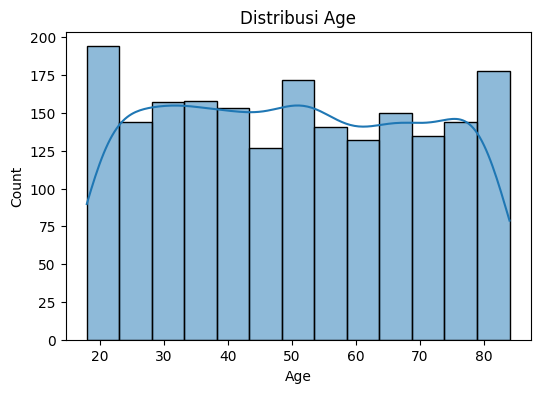

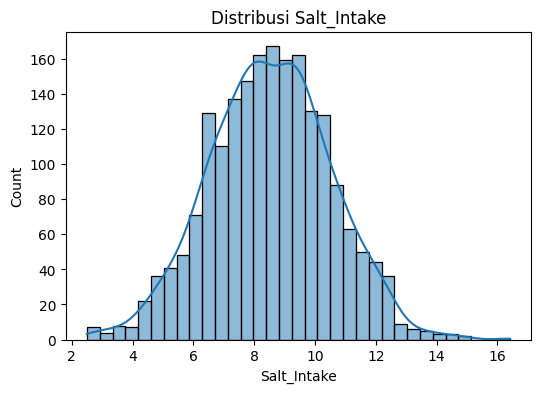

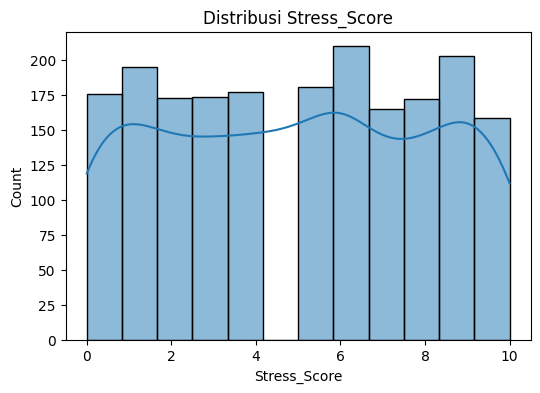

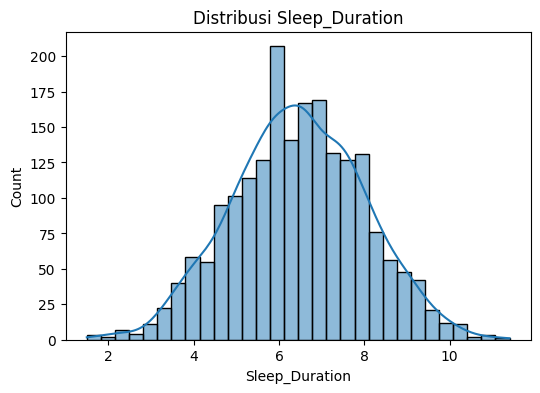

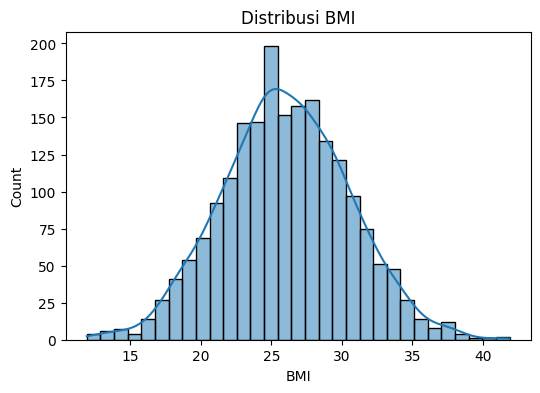

In [139]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

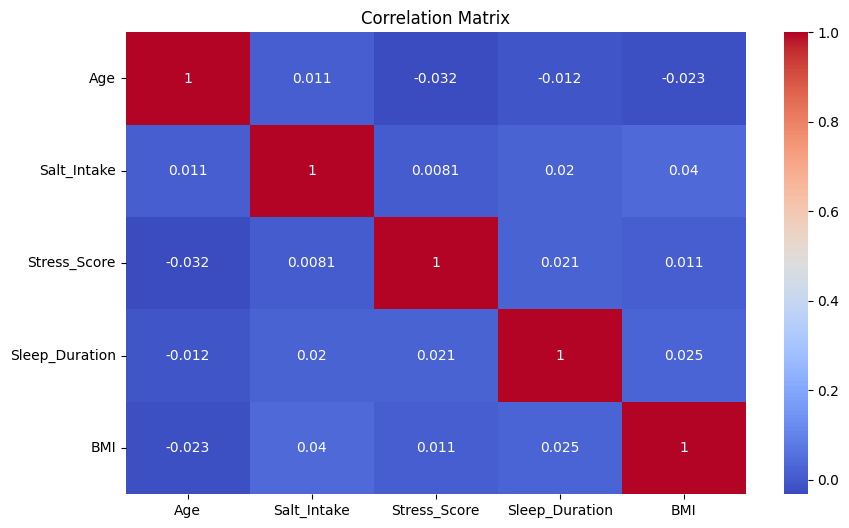

In [140]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Encoding

In [158]:
df_clean = df.copy()
encoders = {}

for col in cat_cols:
    if col != 'Has_Hypertension':
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        encoders[col] = le  

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_clean['Has_Hypertension'])

X = df_clean.drop(columns=['Has_Hypertension'])
print("Jumlah fitur setelah encoding:", X.shape)
X.head()

Jumlah fitur setelah encoding: (1985, 10)


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status
0,69,8.0,9,1,6.4,25.8,3,1,1,0
1,32,11.7,10,1,5.4,23.4,3,0,1,0
2,78,9.5,3,1,7.1,18.7,3,0,2,0
3,38,10.0,10,0,4.2,22.1,0,0,1,0
4,41,9.8,1,2,5.8,16.2,4,0,2,0


#### Cek Class Balance

Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64


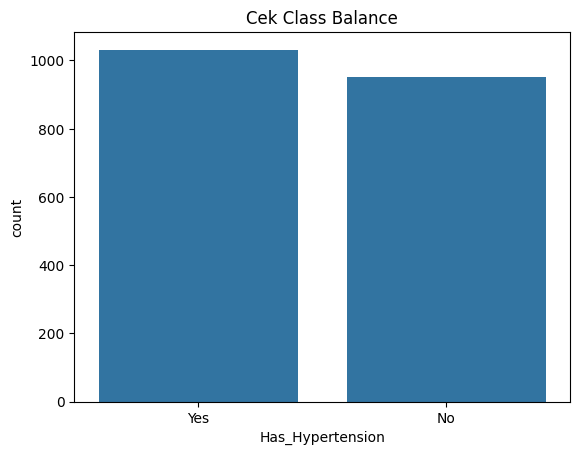

In [142]:
print(df['Has_Hypertension'].value_counts())
sns.countplot(x='Has_Hypertension', data=df)
plt.title("Cek Class Balance")
plt.show()

#### Train-Test Data Split (K-Fold Cross Validation)

In [143]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Modeling

In [225]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, criterion="entropy", min_samples_leaf=1, min_samples_split=10),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000))
    ]),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
}

#### Training Data

In [226]:
results = [] 
predictions = {} 
for name, model in models.items(): 
    print(f"\n===== {name} =====") 
    y_pred = cross_val_predict(model, X, y, cv=cv) 
    predictions[name] = y_pred 
    acc = accuracy_score(y, y_pred) 
    prec = precision_score(y, y_pred) 
    rec = recall_score(y, y_pred) 
    f1 = f1_score(y, y_pred) 
    results.append({ "Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1 }) 
    print(classification_report(y, y_pred))


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       953
           1       0.97      0.97      0.97      1032

    accuracy                           0.97      1985
   macro avg       0.97      0.97      0.97      1985
weighted avg       0.97      0.97      0.97      1985


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       953
           1       0.98      0.96      0.97      1032

    accuracy                           0.97      1985
   macro avg       0.97      0.97      0.97      1985
weighted avg       0.97      0.97      0.97      1985


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       953
           1       0.84      0.83      0.83      1032

    accuracy                           0.83      1985
   macro avg       0.83      0.83      0.

#### Result

In [227]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,Precision,Recall,F1
4,AdaBoost,1.000000,1.000000,1.000000,1.000000
5,Gradient Boosting,0.990428,0.993184,0.988372,0.990772
0,Decision Tree,0.968766,0.971790,0.968023,0.969903
1,Random Forest,0.968766,0.984032,0.955426,0.969518
3,Naive Bayes,0.851385,0.832882,0.893411,0.862085
2,Logistic Regression,0.826196,0.835777,0.828488,0.832117


#### Confusion Matrix

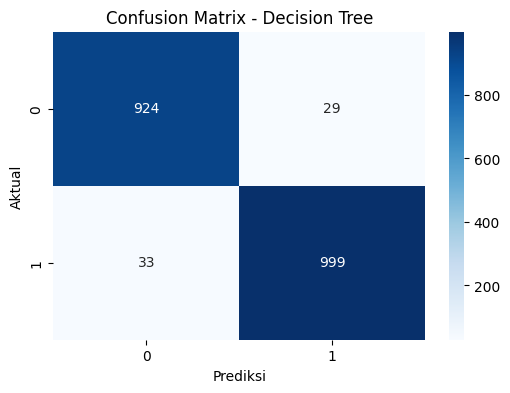

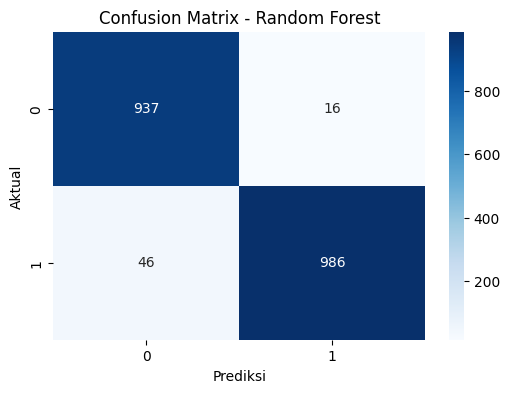

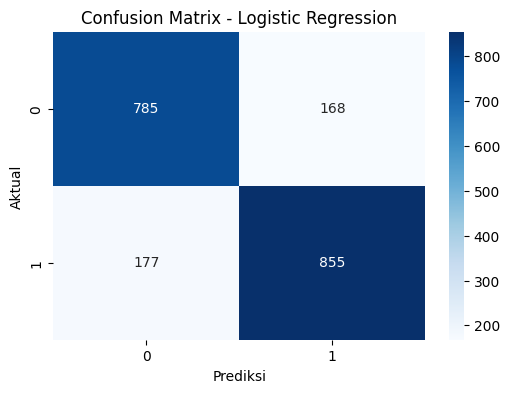

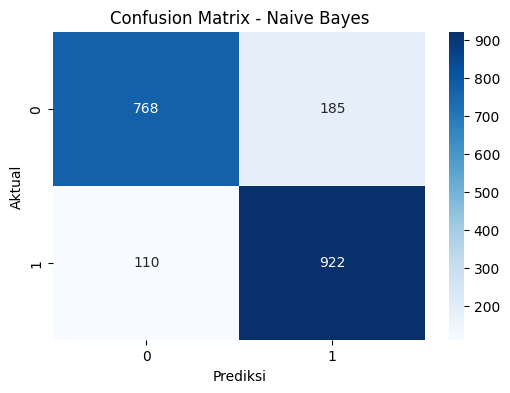

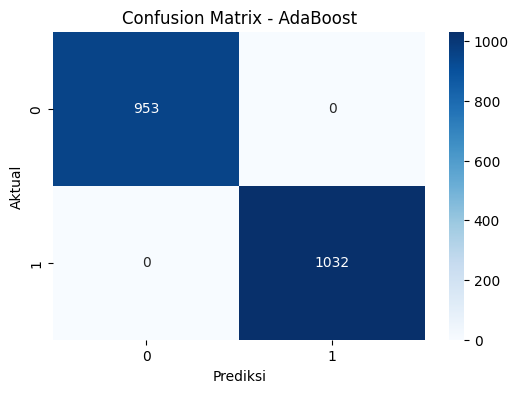

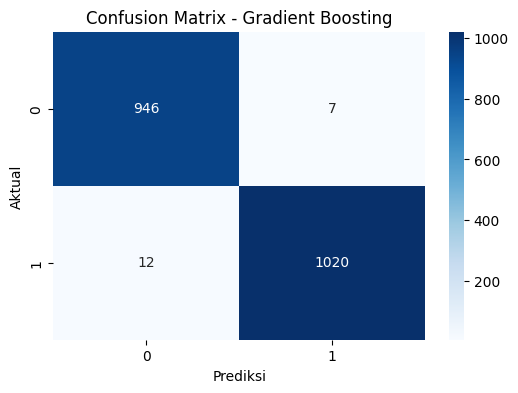

In [228]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

#### Feature Importance

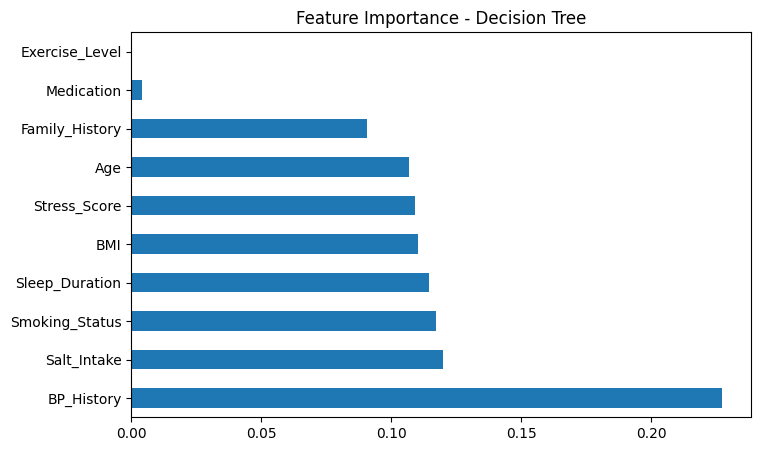

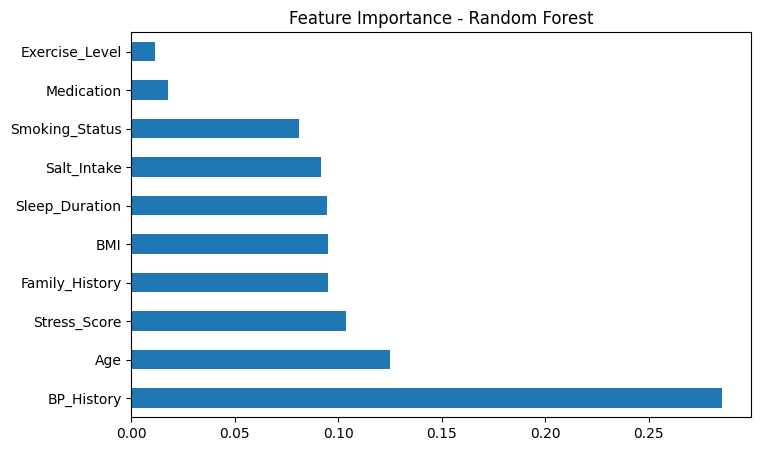

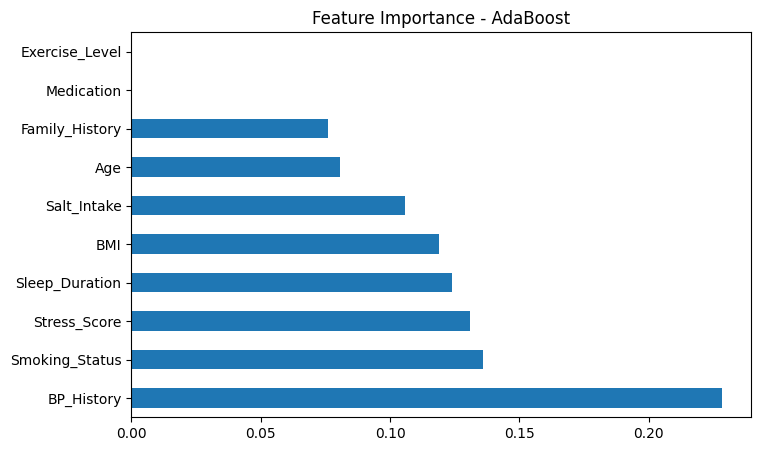

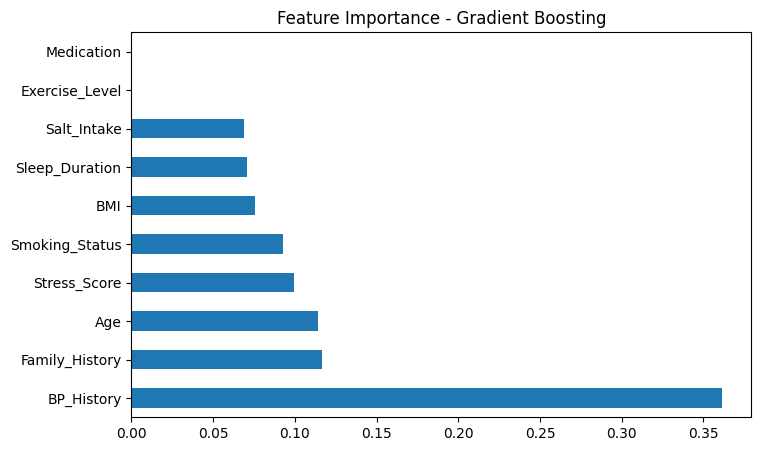

In [229]:
for name, model in models.items():
    try:
        model.fit(X, y)
        
        if hasattr(model, 'feature_importances_'):
            importance = pd.Series(model.feature_importances_, index=X.columns)
            
            plt.figure(figsize=(8,5))
            importance.nlargest(10).plot(kind='barh')
            plt.title(f'Feature Importance - {name}')
            plt.show()
    
    except:
        print(f"{name} tidak memiliki feature importance")